# Importing the dataset

In [2]:
import pandas as pd
import numpy as np

filepath = r"https://raw.githubusercontent.com/UlvenRev/Dropout-and-Burnout-Prediction-with-Logistic-Regression/refs/heads/main/Burnout%20%26%20Dropout%20Predictions/student_burnout_dropout_dataset_2.csv"
student_data = pd.read_csv(filepath, index_col="Student_ID")

student_data.head()

,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,Sleep_Hours,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
Student_ID,,,,,,,,,,,,,,,,,,,,,
STU00001,23,Female,2,Science,Hostel,93.0,4.1,7.13,2.0,6.2,...,Upper-Middle,5.5,10.0,4.0,NaN,7.0,NaN,No,Low,No
STU00002,20,Female,4,Engineering,Day Scholar,94.3,0.0,10.00,0.0,NaN,...,Low,3.7,4.0,5.5,5.1,9.3,2.8,Yes,Medium,Yes
STU00003,24,Male,2,Business,PG/Rented,61.2,2.6,8.02,0.0,4.2,...,Middle,4.8,8.1,9.0,5.2,5.7,5.4,No,High,Yes
STU00004,21,Female,4,Medicine,Hostel,66.9,3.1,5.34,1.0,5.7,...,Lower-Middle,7.0,6.6,2.8,4.2,5.1,3.9,No,High,Yes
STU00005,23,Female,1,Engineering,NaN,84.8,2.9,4.45,1.0,8.0,...,Lower-Middle,1.3,7.3,0.9,6.4,8.1,5.1,No,Low,No


### Variables for prediction (targets): `Burnout_Level` (Low/Medium/High) and `Dropout_Risk` (Yes/No)


In [3]:
# Making a copy of the dataset with which we will work:
student_data_copy = student_data.copy()

___
# Step 1: Choosing the target `y` and features `X`

When your target is a **string** type, you can either encode it to a number of leave as-is, if you don't need it in any particular order.

In this file, I'm going to encode both target variables just to test how it works (but in other files I will be using the string targets right away):

In [4]:
from sklearn.preprocessing import OrdinalEncoder

dropout_encoder = OrdinalEncoder(categories=[["No", "Yes"]])
student_data_copy["Dropout_Risk"] = dropout_encoder.fit_transform(student_data_copy[["Dropout_Risk"]]).ravel()

burnout_encoder = OrdinalEncoder(categories=[["Low", "Medium", "High"]])
student_data_copy["Burnout_Level"] = burnout_encoder.fit_transform(student_data_copy[["Burnout_Level"]]).ravel()

Now we can assign the binary target into our `y`:

In [5]:
y = student_data_copy["Dropout_Risk"]

Now we need to choose the **features** or, more specifically, the **feature names** which we will then use to select the **columns** into `X`. They can be BOTH numerical and string columns, but string columns you will to **encode** the same way you did with the targets (we will do it later).

For now we need to choose the features. Start with numerical columns:

In [6]:
numerical_features = student_data_copy.select_dtypes(include="number")  # Returns a DataFrame
numerical_features = numerical_features.drop(columns=["Dropout_Risk", "Burnout_Level"])  # Removing the targets
numerical_features = numerical_features.columns
print(numerical_features)

Index(['Age', 'Year_of_Study', 'Attendance_Percent', 'Study_Hours_Per_Day',
       'Previous_GPA', 'Backlogs', 'Sleep_Hours', 'Screen_Time_Hours',
       'Exercise_Freq_Per_Week', 'Social_Activity_Score',
       'Financial_Stress_Score', 'Family_Support_Score', 'Stress_Level',
       'Anxiety_Score', 'Motivation_Score', 'Peer_Pressure_Score'],
      dtype='str')


Now we can check how many of these columns **correlate with each other**. If the correlation is high, then **one variable can be derived from another** and there's no point in taking both of them as feature, it only adds extra work. 

So we takes only those with **low correlation**.

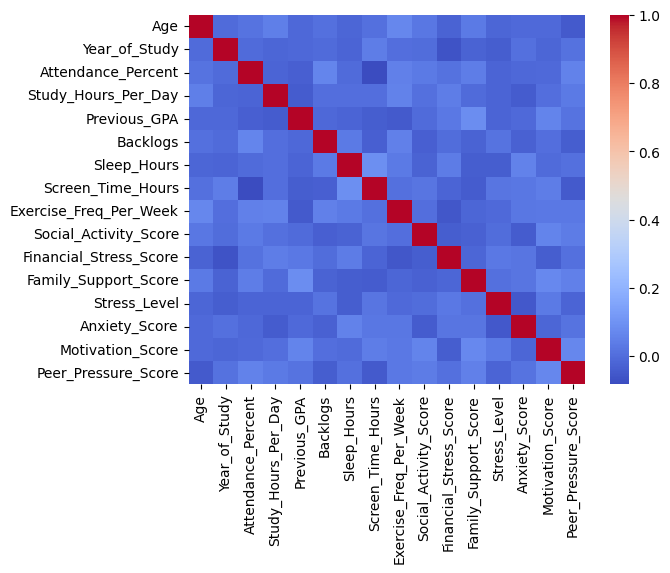

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(student_data_copy[numerical_features].corr(), cmap="coolwarm")
plt.show()

As expected, there's **no visible correlation** between the variables, meaning *one can't be derived from another*. If it could be, then one of them would be redundant, but not in this case.

So for the first training run we can take **all numerical columns as features**.

Now for the STRING columns:

In [8]:
string_features = student_data_copy.select_dtypes(include="object")
string_features = string_features.columns
print(string_features)

Index(['Gender', 'Department', 'Residence_Type', 'Part_Time_Job',
       'Family_Income_Bracket', 'Counseling_Access'],
      dtype='str')


C:\Users\diach\AppData\Local\Temp\ipykernel_25164\1077258812.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_features = student_data_copy.select_dtypes(include="object")


We see that we don't have our targets here, because we've already encoded them as numbers.

So our string columns are all good and we don't need to encode them.

In [9]:
feature_names = np.concatenate((string_features, numerical_features))  # np.concatenate because both are NumPy arrays
print(feature_names)

['Gender' 'Department' 'Residence_Type' 'Part_Time_Job'
 'Family_Income_Bracket' 'Counseling_Access' 'Age' 'Year_of_Study'
 'Attendance_Percent' 'Study_Hours_Per_Day' 'Previous_GPA' 'Backlogs'
 'Sleep_Hours' 'Screen_Time_Hours' 'Exercise_Freq_Per_Week'
 'Social_Activity_Score' 'Financial_Stress_Score' 'Family_Support_Score'
 'Stress_Level' 'Anxiety_Score' 'Motivation_Score' 'Peer_Pressure_Score']


Finally we can select the COLUMNS of the `student_data_copy` that will be our features `X`.

In [10]:
X = student_data_copy[feature_names]  # This is a DataFrame!

___
# Step 2: Splitting the dataset into training and validation data

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=0)

___
# Step 3: Dealing with missing values

Now we can deal with the missing values (if they are present). We're dealing with them ONLY in `X_train` and `X_valid`, because `y_train` and `y_valid` we use **only for the targets**, which (hopefully) don't have any missing values - we will check it later.

Why did we SPLIT first and ONLY THEN deal with missing values? Explanation in simple words:

### Important note: Do you deal with missing values BEFORE or AFTER splitting into training and validation data?

Filling in missing values **before** splitting can cause **data leakage**. For example, if you use stuff like mean, median or most frequient value to determine what to fill the missing value with, you will also be deriving this from the data that will end up in you **validation set**, which can make the performance look better than it actually is. But if you just use the constant value to fil the missing values, it won't create any leakage.

Still, to not accidentally make a mistake on this, it's better to SPLIT first and then FILL.

### Find out which **features** in `X_train` have missing values:
(and they will be the SAME for `X_valid`) By now you should forget about `X` existing at all - it's the FULL dataset, not the one we splitted, so we **won't** be working with `X` and only with `X_train` and `X_valid`.

In [12]:
cols_with_missing = [col for col in X_train.columns if X_train[col].isnull().any()]  # Names of the columns

X_train[cols_with_missing].dtypes  # Their types

Gender                        str
Department                    str
Residence_Type                str
Part_Time_Job                 str
Family_Income_Bracket         str
Attendance_Percent        float64
Study_Hours_Per_Day       float64
Previous_GPA              float64
Backlogs                  float64
Sleep_Hours               float64
Screen_Time_Hours         float64
Social_Activity_Score     float64
Financial_Stress_Score    float64
Family_Support_Score      float64
Stress_Level              float64
Anxiety_Score             float64
Motivation_Score          float64
Peer_Pressure_Score       float64
dtype: object

And the same is for `X_valid`, so we will just repeat everything we do to `X_train` with `X_valid`:

In [13]:
X_valid[cols_with_missing].dtypes

Gender                        str
Department                    str
Residence_Type                str
Part_Time_Job                 str
Family_Income_Bracket         str
Attendance_Percent        float64
Study_Hours_Per_Day       float64
Previous_GPA              float64
Backlogs                  float64
Sleep_Hours               float64
Screen_Time_Hours         float64
Social_Activity_Score     float64
Financial_Stress_Score    float64
Family_Support_Score      float64
Stress_Level              float64
Anxiety_Score             float64
Motivation_Score          float64
Peer_Pressure_Score       float64
dtype: object

So now we clearly see which missing values should be **numerical** and which should be **strings**.

In [14]:
X_train["Gender"].unique()

<StringArray>
['Male', 'Female', 'Other', nan]
Length: 4, dtype: str

So here it's probably logical to enter `Other` in place of `nan` instead of trying to guess wether a person was Male or Female.

In [15]:
X_train["Gender"] = X_train["Gender"].fillna("Other")
X_valid["Gender"] = X_valid["Gender"].fillna("Other")

# Check that we don't have the "nan" value anymore
X_train["Gender"].unique()

<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

Next is `Department`:

In [16]:
X_train["Department"].unique()

<StringArray>
['Arts', 'Science', 'Engineering', 'Business', 'Medicine', 'Law', nan]
Length: 7, dtype: str

Same as before, it's probably best to insert `Other` for missing values, in case the person didn't want to say where they are studying.

In [17]:
X_train["Department"] = X_train["Department"].fillna("Other")
X_valid["Department"] = X_valid["Department"].fillna("Other")

# Check that we don't have the "nan" value anymore
X_train["Department"].unique()

<StringArray>
['Arts', 'Science', 'Engineering', 'Business', 'Medicine', 'Law', 'Other']
Length: 7, dtype: str

Next is `Residence_Type`:

In [18]:
X_train["Residence_Type"].unique()

<StringArray>
['Hostel', 'Day Scholar', nan, 'PG/Rented']
Length: 4, dtype: str

In [19]:
# Same logic:
X_train["Residence_Type"] = X_train["Residence_Type"].fillna("Other")
X_valid["Residence_Type"] = X_valid["Residence_Type"].fillna("Other")

# Check that we don't have the "nan" value anymore
X_train["Residence_Type"].unique()

<StringArray>
['Hostel', 'Day Scholar', 'Other', 'PG/Rented']
Length: 4, dtype: str

Next is `Part_Time_Job`:

In [20]:
X_train["Part_Time_Job"].unique()

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

Here we can assume that `nan` value means `No` (the person skipped the question because they don't work). Of course it's not necessarily true, but just for it to be different from what we did above, we will fill missing values with `No`:

In [21]:
X_train["Part_Time_Job"] = X_train["Part_Time_Job"].fillna("No")
X_valid["Part_Time_Job"] = X_valid["Part_Time_Job"].fillna("No")

# Check that we don't have the "nan" value anymore
X_train["Part_Time_Job"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Next is `Family_Income_Bracket`:

In [22]:
X_train["Family_Income_Bracket"].unique()

<StringArray>
['Low', 'Middle', 'Upper-Middle', 'High', 'Lower-Middle', nan]
Length: 6, dtype: str

Just to do something different, here we can use `SimpleImputer` and replace missing values with the **most popular value**:

In [23]:
from sklearn.impute import SimpleImputer

income_bracket_imputer = SimpleImputer(strategy="most_frequent")
X_train["Family_Income_Bracket"] = income_bracket_imputer.fit_transform(X_train[["Family_Income_Bracket"]]).ravel()
X_valid["Family_Income_Bracket"] = income_bracket_imputer.transform(X_valid[["Family_Income_Bracket"]]).ravel()

# Check that we don't have the "nan" value anymore
X_train["Family_Income_Bracket"].unique()

<StringArray>
['Low', 'Middle', 'Upper-Middle', 'High', 'Lower-Middle']
Length: 5, dtype: str

Check again for columns with missing values:

In [24]:
numerical_cols_with_missing = [col for col in X_train.columns if X_train[col].isnull().any()]  # Names of the columns

X_train[numerical_cols_with_missing].dtypes  # Their types

Attendance_Percent        float64
Study_Hours_Per_Day       float64
Previous_GPA              float64
Backlogs                  float64
Sleep_Hours               float64
Screen_Time_Hours         float64
Social_Activity_Score     float64
Financial_Stress_Score    float64
Family_Support_Score      float64
Stress_Level              float64
Anxiety_Score             float64
Motivation_Score          float64
Peer_Pressure_Score       float64
dtype: object

Now we got rid of all missing values inside string columns, so they're not showing here anymore!

All the other values are fully **numerical**, so it makes sense to fill them in using `SimpleImputer` and let it decide how to best fill these values:

In [25]:
numerical_imputer = SimpleImputer()

for col in numerical_cols_with_missing:
    X_train[col] = numerical_imputer.fit_transform(X_train[[col]]).ravel()
    X_valid[col] = numerical_imputer.transform(X_valid[[col]]).ravel()


final_cols_with_missing = [col for col in X_train.columns if X_train[col].isnull().any()]  # Names of the columns
print(X_train[final_cols_with_missing].dtypes)  # Their types

final_cols_with_missing = [col for col in X_valid.columns if X_valid[col].isnull().any()]  # Names of the columns
print(X_valid[final_cols_with_missing].dtypes)

Series([], dtype: object)
Series([], dtype: object)


We successfully got rid of all the missing values in all columns in both `X_train` and `X_valid`!

___
# Step 4: Preprocessing categorical variables

Just like we encoded our target values from strings into numbers, we need to do the same with the string variables in our **features**, because ML models work with numbers. String variables usually take a **limited** number of values (Male/Female), which is why they are called **categorical variables**.

In [26]:
# Making copies to avoid changing original data
encoded_X_train = X_train.copy()
encoded_X_valid = X_valid.copy()

categorical_cols = [col for col in encoded_X_train.columns if encoded_X_train[col].dtype == "str"]  # Selecting string columns
print(categorical_cols)

['Gender', 'Department', 'Residence_Type', 'Part_Time_Job', 'Family_Income_Bracket', 'Counseling_Access']


Now, **be careful here**! There are **two** types of encoding:
1. **Ordinal Encoding** - when you have clear ordering you can make, e.g. Low (0) < Medium (1) < High (2). You **CANNOT** apply it to columns like `Department` because you can't say that Business > Law.
2. **One-Hot Encoding** - needed specifically when you don't have an order. So instead of giving numbers 0, 1, 2 etc., you make **additional columns** where you mark which value is **present** with a 1 and which is not with 0.

Columns `Gender`, `Part_Time_Job`, `Family_Income_Bracket` and `Counseling_Access` have *ordered values*, so we can use Ordinal Encoding on them.
Columns `Department` and `Residence_Type` don't have an ordering, so we need to use One-Hot Encoding.

In [27]:
ordinal_cols = ["Gender", "Part_Time_Job", "Family_Income_Bracket", "Counseling_Access"]
OneHot_cols = ["Department", "Residence_Type"]

ordinal_encoder = OrdinalEncoder()
encoded_X_train[ordinal_cols] = ordinal_encoder.fit_transform(X_train[ordinal_cols])  # Note: not ravel() here bc we're assigning to MULTIPLE columns at once
encoded_X_valid[ordinal_cols] = ordinal_encoder.transform(X_valid[ordinal_cols])

# Check the encoded results against the original
print(X_train[ordinal_cols].head())
print(encoded_X_train[ordinal_cols].head())

            Gender Part_Time_Job Family_Income_Bracket Counseling_Access
Student_ID                                                              
STU00417      Male            No                   Low                No
STU00294    Female           Yes                Middle                No
STU00557    Female           Yes                Middle               Yes
STU00272      Male            No                Middle                No
STU00506      Male            No          Upper-Middle                No
            Gender  Part_Time_Job  Family_Income_Bracket  Counseling_Access
Student_ID                                                                 
STU00417       1.0            0.0                    1.0                0.0
STU00294       0.0            1.0                    3.0                0.0
STU00557       0.0            1.0                    3.0                1.0
STU00272       1.0            0.0                    3.0                0.0
STU00506       1.0            0.0

With binary values like Male/Female or Yes/No we don't need to bother what Ordinal Encoder marks as 0 and what as 1. 

But I'm suspicious about how it assigned numbers to `Family_Income_Bracket`, so we should check it:

In [28]:
print(X_train["Family_Income_Bracket"].unique())
print(encoded_X_train["Family_Income_Bracket"].unique())

<StringArray>
['Low', 'Middle', 'Upper-Middle', 'High', 'Lower-Middle']
Length: 5, dtype: str
[1. 3. 4. 0. 2.]


So we can see it assigned the numbers slightly weird. I want to make it Low (0) < Lower-Middle (1) < Middle (2) < Upper-Middle (3) < High (4).

We can redo the encoding again:

In [29]:
bracket_encoder = OrdinalEncoder(categories=[["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"]])
encoded_X_train["Family_Income_Bracket"] = bracket_encoder.fit_transform(X_train[["Family_Income_Bracket"]]).ravel()  # Good thing we have the original X_train data! That's where the TEXT values are still stored
encoded_X_valid["Family_Income_Bracket"] = bracket_encoder.transform(X_valid[["Family_Income_Bracket"]]).ravel()  # Note: and we need ravel() bc we're working with ONE column at a time (and DOUBLE brackets!!! [["..."]])


Check again:

In [30]:
print(X_train[ordinal_cols].head())
print(encoded_X_train[ordinal_cols].head())

            Gender Part_Time_Job Family_Income_Bracket Counseling_Access
Student_ID                                                              
STU00417      Male            No                   Low                No
STU00294    Female           Yes                Middle                No
STU00557    Female           Yes                Middle               Yes
STU00272      Male            No                Middle                No
STU00506      Male            No          Upper-Middle                No
            Gender  Part_Time_Job  Family_Income_Bracket  Counseling_Access
Student_ID                                                                 
STU00417       1.0            0.0                    0.0                0.0
STU00294       0.0            1.0                    2.0                0.0
STU00557       0.0            1.0                    2.0                1.0
STU00272       1.0            0.0                    2.0                0.0
STU00506       1.0            0.0

Much better.

Now we need to encode, using `One-Hot Encoder`, the following columns:

In [31]:
X_train[OneHot_cols].head()

,Department,Residence_Type
Student_ID,,
STU00417,Arts,Hostel
STU00294,Science,Day Scholar
STU00557,Engineering,Other
STU00272,Business,Hostel
STU00506,Medicine,Day Scholar


In [32]:
encoded_X_train.head()

,Gender,Department,Residence_Type,Part_Time_Job,Family_Income_Bracket,Counseling_Access,Age,Year_of_Study,Attendance_Percent,Study_Hours_Per_Day,...,Sleep_Hours,Screen_Time_Hours,Exercise_Freq_Per_Week,Social_Activity_Score,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score
Student_ID,,,,,,,,,,,,,,,,,,,,,
STU00417,1.0,Arts,Hostel,0.0,0.0,0.0,19,3,80.500000,3.5,...,4.5,6.2,4,2.900000,3.7,6.2,7.0,2.3,3.100000,4.1
STU00294,0.0,Science,Day Scholar,1.0,2.0,0.0,24,4,77.035791,2.7,...,5.3,12.0,2,4.887544,4.2,3.0,6.0,9.5,4.700000,4.8
STU00557,0.0,Engineering,Other,1.0,2.0,1.0,20,2,66.600000,3.2,...,7.6,6.0,0,6.200000,5.8,4.6,6.4,9.5,4.800000,2.5
STU00272,1.0,Business,Hostel,0.0,2.0,0.0,19,2,66.500000,6.2,...,8.1,5.6,3,4.887544,7.2,10.0,7.4,5.2,5.521127,6.2
STU00506,1.0,Medicine,Day Scholar,0.0,3.0,0.0,19,1,80.000000,2.8,...,5.7,7.9,1,2.500000,9.1,7.7,10.0,2.6,7.800000,2.7


In [33]:
from sklearn.preprocessing import OneHotEncoder

OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(X_train[["Department", "Residence_Type"]]), 
                             columns=OH_encoder.get_feature_names_out(["Department", "Residence_Type"]))
OH_cols_valid = pd.DataFrame(OH_encoder.transform(X_valid[["Department", "Residence_Type"]]),
                             columns=OH_encoder.get_feature_names_out(["Department", "Residence_Type"]))

# One-Hot Encoding removed index, so we put it back in (needed for pd.concat so it knows which row goes where)
OH_cols_train.index = X_train.index
OH_cols_valid.index = X_valid.index

# From encoded_X_train REMOVE the string columns we just encoded (Department and Residence Type)
num_X_train = encoded_X_train.drop(["Department", "Residence_Type"], axis=1)
num_X_valid = encoded_X_valid.drop(["Department", "Residence_Type"], axis=1)

# Combine numerical and encoded columns into our final set of features
final_X_train = pd.concat([num_X_train, OH_cols_train], axis=1)
final_X_valid = pd.concat([num_X_valid, OH_cols_valid], axis=1)

# Ensure all columns names are strings - some models may throw an error if names and NOT strings
final_X_train.columns = final_X_train.columns.astype(str)
final_X_valid.columns = final_X_valid.columns.astype(str)

final_X_train.head()

,Gender,Part_Time_Job,Family_Income_Bracket,Counseling_Access,Age,Year_of_Study,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Department_Business,Department_Engineering,Department_Law,Department_Medicine,Department_Other,Department_Science,Residence_Type_Day Scholar,Residence_Type_Hostel,Residence_Type_Other,Residence_Type_PG/Rented
Student_ID,,,,,,,,,,,,,,,,,,,,,
STU00417,1.0,0.0,0.0,0.0,19,3,80.500000,3.5,7.04,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
STU00294,0.0,1.0,2.0,0.0,24,4,77.035791,2.7,7.52,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
STU00557,0.0,1.0,2.0,1.0,20,2,66.600000,3.2,4.72,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
STU00272,1.0,0.0,2.0,0.0,19,2,66.500000,6.2,6.01,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
STU00506,1.0,0.0,3.0,0.0,19,1,80.000000,2.8,10.00,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [34]:
final_X_valid.head()

,Gender,Part_Time_Job,Family_Income_Bracket,Counseling_Access,Age,Year_of_Study,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Department_Business,Department_Engineering,Department_Law,Department_Medicine,Department_Other,Department_Science,Residence_Type_Day Scholar,Residence_Type_Hostel,Residence_Type_Other,Residence_Type_PG/Rented
Student_ID,,,,,,,,,,,,,,,,,,,,,
STU00300,1.0,1.0,0.0,0.0,18,1,62.9,2.6,6.06,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
STU00501,0.0,0.0,4.0,0.0,19,2,56.9,5.6,5.77,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
STU00304,2.0,0.0,2.0,0.0,25,4,62.7,4.9,5.88,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
STU00041,0.0,1.0,1.0,0.0,21,2,90.3,3.2,7.79,3.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
STU00496,1.0,0.0,0.0,0.0,23,1,86.4,3.0,8.31,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


Both `final_X_train` and `final_X_valid` seem to be okay! We can move on!
___
# Step 5: Selecting which model to use

You have **two** types of models you can use for predictions:
- **Regressors**: used to predict *continuous* values like price, temperature, exam score etc.
- **Classifiers**: predicts an actual *class*, e.g. 0/1.

After this you can **test** how good the model performs by using:
- Accuracy score, ROC AUC score, F-score etc. (classifiers)
- Mean Absolute Error (regressors)

Most common models that can be used:
- Random Forest Classifier (not Regressor) - tree-based, builds trees independently rather than sequentially correcting errors (boosting). Easy to tune with parameters.
- Logistic Regression (named Regression but is actually a Classifier!) - simple linear model, but may underperform if the data has a non-linear relationship
- XGBoost Classifier - tree-based, each tree corrects errors of the previous tree and gives better predictions

### Deciding which model to pick using Cross-Validation

We can test each model using **Cross-Validation** and the AUC score. 

Cross-Validation means we're splitting the dataset into 5 chunks, train the model on 4 of them and compare to the fifth. Then rotate to choose the next chunk as the one for validation and train on the new 4 chunks and so on. This ensures the model always looks at new data despite us having a limited amount of it and it gives a more accurate understand of how well the model predicts. 

To deside which model is the most accurate, we will use the AUC score, calculated at each rotation of Cross-Validation.

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=0),
    "XGBoost": XGBClassifier(random_state=0)
}

for name, model in models.items():
    auc_scores = cross_val_score(model, final_X_train, y_train, cv=5, scoring="roc_auc")
    print(f"{name}: AUC = {auc_scores.mean():.4f}")

Logistic Regression: AUC = 0.7538
Random Forest: AUC = 0.6933
XGBoost: AUC = 0.6935


Logistic Regression has the highest AUC score, so it's safer to choose this model. And it's logical - our data most-likely has a LINEAR relation needed for Logistic Regression. Say a person didn't sleep well + studies a lot + works part time and it all accumuates to them dropping out. 

So Logistic Regression will be pretty accurate here.

### Training and finetuning the model using `GridSearchCV`

Grid Search essentially just takes each value inside `param_grid` and applies to the `LogisticRegression` model, runs cross-validation, records the value and moves on to the next. In the end it gives you the best model. 

`param_grid` can also hold more than just one key-value pair - it can hold *any* parameters applicable to `LogisticRegression` which you want to test. Just in this case `C` matters the most (controls regularization strenght to prevent overfitting), so I'm testing only for it.

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=5,
    scoring="roc_auc"
)

grid_search.fit(final_X_train, y_train)  # This line actually trains all the separate Logistic Regression models

print("Best params: ", grid_search.best_params_)
print("Best AUC: ", grid_search.best_score_)

best_model = grid_search.best_estimator_  # An ALREADY TRAINED Logistic Regression model

Best params:  {'C': 0.1}
Best AUC:  0.7615267232767233


Now inside `best_model` we have the best `LogisticRegression` model with best parameters that give the highest AUC. 

And a good thing about grid search is that for choosing the best model, it has to *train each one first* to be able to evaluate how good it is. So the model that we **get back** is **already trained** on our `final_X_train`!

So now we can use it as usual for the predictions.

___
# Step 6: Predicting the target value


In [37]:
predictions = best_model.predict(final_X_valid)

___
# Step 7: Using SHAP to see which features are useful (and which we can remove)

A SHAP value is a score that tells you how much a specific feature (or variable) contributed to a model's prediction. Features that had a **low impact** on predictions can be left out and the model can be retrained. If it performs better - good, simpler is often better due to a smaller overfitting risk, easier explanation and a model can fit a cleaner, more stable linear boundary. If it performs worse - we may have removed an important feature that had low impact, but in combination with other features was actually useful.

Background dataset has 600 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=600 when initializing the masker.


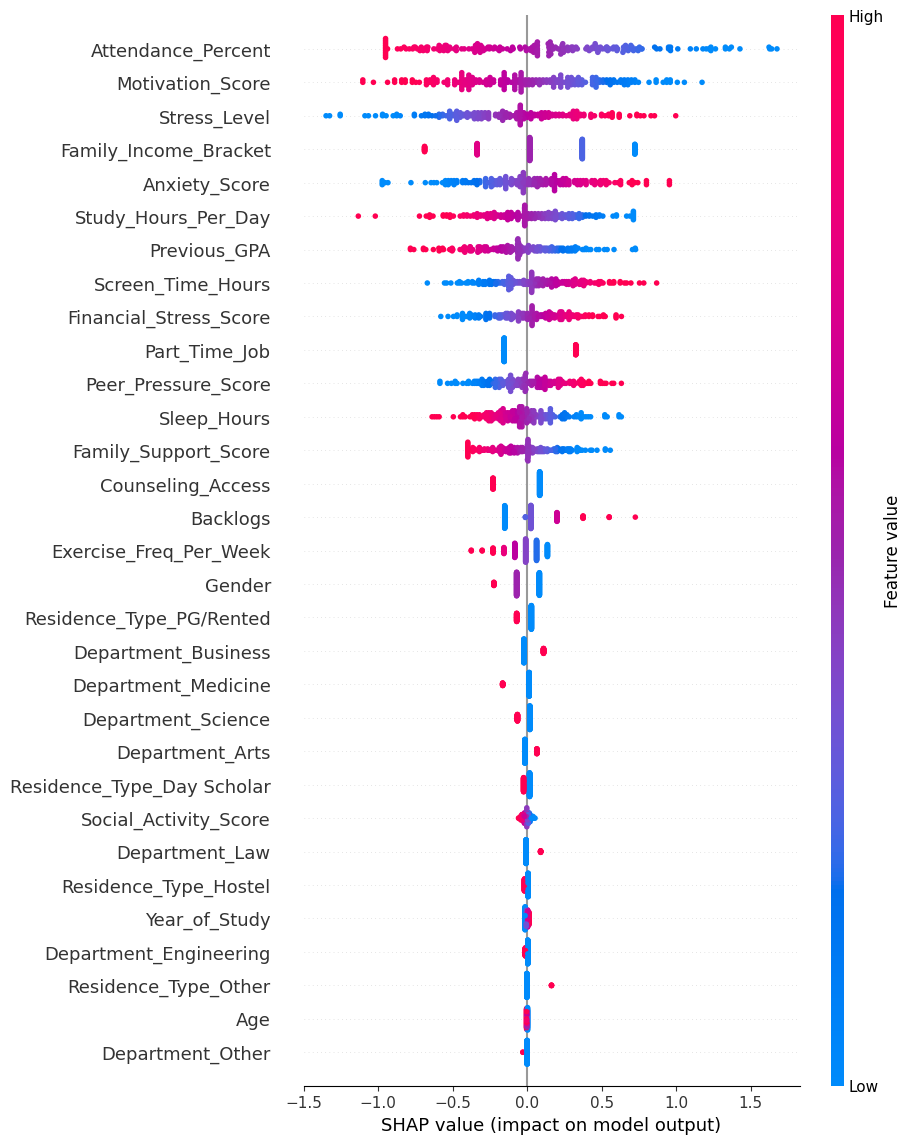

In [38]:
import shap

explainer = shap.LinearExplainer(best_model, final_X_train)
shap_values = explainer(final_X_valid)

shap.plots.beeswarm(shap_values, max_display=final_X_train.shape[1])

SHAP graph sorts features from highest impact to lowest. I selected the features I want to keep and the ones that we can drop:

In [39]:
high_impact = ["Attendance_Percent", "Motivation_Score", "Stress_Level", "Family_Income_Bracket", "Anxiety_Score", "Study_Hours_Per_Day", "Previous_GPA", "Screen_Time_Hours", "Financial_Stress_Score", "Part_Time_Job", "Peer_Pressure_Score", "Sleep_Hours", "Family_Support_Score", "Backlogs", "Exercise_Freq_Per_Week"]

low_impact = [col for col in final_X_train.columns if col not in high_impact]
print(low_impact)

['Gender', 'Counseling_Access', 'Age', 'Year_of_Study', 'Social_Activity_Score', 'Department_Arts', 'Department_Business', 'Department_Engineering', 'Department_Law', 'Department_Medicine', 'Department_Other', 'Department_Science', 'Residence_Type_Day Scholar', 'Residence_Type_Hostel', 'Residence_Type_Other', 'Residence_Type_PG/Rented']


___
# Step 8: Retraining the model based on new features

Note: You **don't have to split** your data again or select a new `X` that won't have the low impact columns we identified above. 

This is because you're dropping **columns**, not rows, so you will have the **exact same rows** as the ones you have in `final_X_train` and `final_X_valid` already. You only need to drop the columns from these sets and then retrain the model based on new reduced data.

In [40]:
from sklearn.metrics import roc_auc_score

# Drop the low impact columns
final_X_train_reduced = final_X_train.drop(columns=low_impact)
final_X_valid_reduced = final_X_valid.drop(columns=low_impact)

# Retrain the SAME model with new features
reduced_model = LogisticRegression(max_iter=2000, C=grid_search.best_params_["C"])  # We CAN'T use best_model because it already holds a model TRAINED on previous features, on final_X_train
reduced_model.fit(final_X_train_reduced, y_train)

# Compare against our best model
preds_reduced = reduced_model.predict(final_X_valid_reduced)
probs_reduced = reduced_model.predict_proba(final_X_valid_reduced)[:, 1]

print("Previous model's AUC: ", grid_search.best_score_)
print("Reduced model's AUC: ", roc_auc_score(y_valid, probs_reduced))


Previous model's AUC:  0.7615267232767233
Reduced model's AUC:  0.8026650391618351


So we see that the new model with reduced featured **performed better** than the one with more features.

However, the high AUC of `0.80` seems suspicious. This *could* be biased, because what we did is:
1. We selected all features, trained the model on them
2. Used the validation set to check our predictions
3. Based on these predictions we **selected which features to drop** - so we **wouldn't know** which features to drop and how they impacted the model, unless we looked at how it performed with the validation set

So the validation set technically **influenced our decision on which features to select**. It's not an "unseen" data anymore. We used it one to help edit the features, and now we're using it **again** to check how new features perform. 

It's a minor bias, but it will be worse and worse if you keep repeating this cycle (check performance, alter features again, test again, alter and so on).

So a way to get the true AUC from these new features is again to use `Cross Validation`, because the rotating 5 chuncks make up the "unseen" data:

In [41]:
auc_scores_reduced = cross_val_score(best_model, final_X_train_reduced, y_train, cv=5, scoring="roc_auc")  # Here we can pass the best_model, since CV will retrain it from scratch
print(f"CV AUC reduced: {auc_scores_reduced.mean():.4f}")

CV AUC reduced: 0.7717


And now we can see that the **actual AUC** from the reduced features is `0.77`, which only slightly bigger than the `0.76` from the model with **all features**. And it's normal - at least we can be more sure in it than in the AUC of `0.80`.